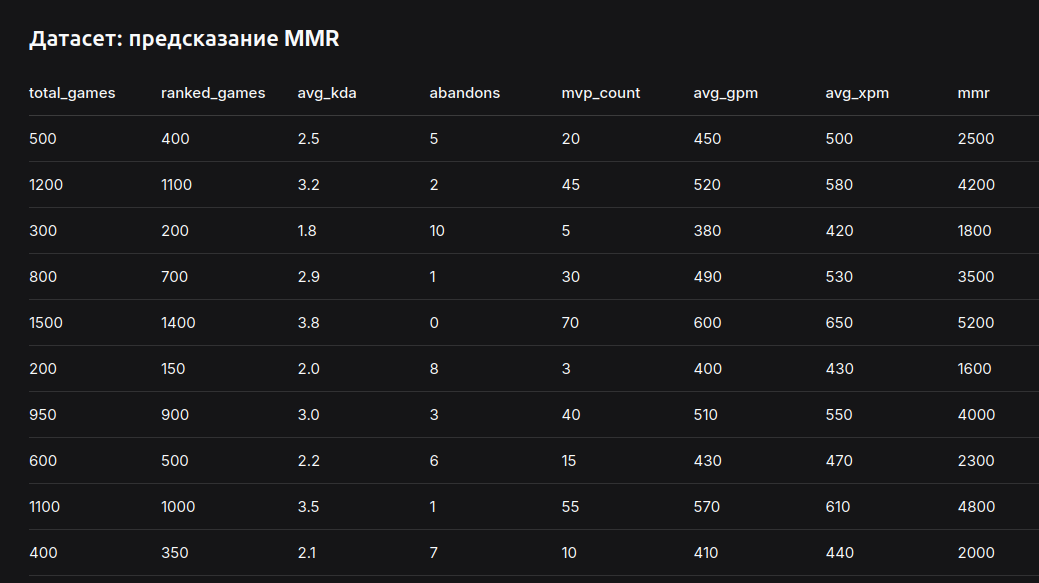

In [1]:
import numpy as np
import sympy as sp

In [2]:
data = np.array([
    [500, 400, 2.5, 5, 20, 450, 500, 2500],
    [1200, 1100, 3.2, 2, 45, 520, 580, 4200],
    [300, 200, 1.8, 10, 5, 380, 420, 1800],
    [800, 700, 2.9, 1, 30, 490, 530, 3500],
    [1500, 1400, 3.8, 0, 70, 600, 650, 5200],
    [200, 150, 2.0, 8, 3, 400, 430, 1600],
    [950, 900, 3.0, 3, 40, 510, 550, 4000],
    [600, 500, 2.2, 6, 15, 430, 470, 2300],
    [1100, 1000, 3.5, 1, 55, 570, 610, 4800],
    [400, 350, 2.1, 7, 10, 410, 440, 2000]
])

In [3]:
X = data[:, :7]

# Добавляем столбец единиц слева
X_with_ones = np.column_stack([np.ones(X.shape[0]), X])

In [4]:
b = data[:, 7]
b

array([2500., 4200., 1800., 3500., 5200., 1600., 4000., 2300., 4800.,
       2000.])

In [5]:
X_with_ones_T = X_with_ones.T

# градиентный спуск <3

In [56]:
# без нормализации

In [52]:
point = np.zeros(8)
step = 0.0000005
n_tier = 1000
mse_history = []

In [53]:
for i in range(n_tier):
    y_pred = X_with_ones @ point

    error = y_pred - b

    mse = np.mean(error**2)
    mse_history.append(mse)

    gradient = (2/len(b)) * X_with_ones_T @ error

    point = point - step * gradient

    if i % 100 == 0:
        print(f'iter: {i}, MSE = {mse:.2f}')

iter: 0, MSE = 11731000.00
iter: 100, MSE = 55737.03
iter: 200, MSE = 55455.05
iter: 300, MSE = 55180.52
iter: 400, MSE = 54912.10
iter: 500, MSE = 54649.54
iter: 600, MSE = 54392.61
iter: 700, MSE = 54141.07
iter: 800, MSE = 53894.72
iter: 900, MSE = 53653.35


In [54]:
point

array([-0.00488961,  0.95596335,  1.48535915,  0.02400659, -0.20255801,
        0.82722536,  1.81922898,  1.14218569])

In [55]:
mse

np.float64(53419.09796078155)

In [ ]:
# пробуем нормализацию

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_with_ones)

In [38]:
point = np.zeros(8)
step = 0.12
n_tier = 100000
mse_history = []

In [39]:
for i in range(n_tier):
    y_pred = X_scaled @ point

    error = y_pred - b

    mse = np.mean(error**2)
    mse_history.append(mse)

    gradient = (2/len(b)) * X_scaled.T @ error

    point = point - step * gradient

    if i % 10000 == 0:
        print(f'iter: {i}, MSE = {mse:.2f}')

iter: 0, MSE = 11731000.00
iter: 10000, MSE = 10195317.97
iter: 20000, MSE = 10195094.72
iter: 30000, MSE = 10195043.56
iter: 40000, MSE = 10195031.78
iter: 50000, MSE = 10195029.07
iter: 60000, MSE = 10195028.45
iter: 70000, MSE = 10195028.30
iter: 80000, MSE = 10195028.27
iter: 90000, MSE = 10195028.26


# метод наименьших квадратов

In [14]:
w = np.linalg.inv(X_with_ones_T @ X_with_ones) @ X_with_ones_T @ b
w

array([1434.525117  ,    3.03417408,   -2.16225334, 1983.93251936,
         29.87900312,   20.13025342,    5.24165391,  -14.78100003])

In [18]:
new_player = np.array([1, 600, 500, 2.8, 2, 25, 480, 520])
new_player

array([  1. , 600. , 500. ,   2.8,   2. ,  25. , 480. , 520. ])

In [19]:
new_player @ w

np.float64(3121.802155043126)

In [20]:
predictions = X_with_ones @ w
predictions

array([2566.78645022, 4163.93883348, 1666.65498048, 3469.95835898,
       5444.03520885, 1725.14130763, 3761.30067399, 2326.62342774,
       4662.0027403 , 2113.55801842])

In [22]:
errors = predictions - b
errors

array([  66.78645022,  -36.06116652, -133.34501952,  -30.04164102,
        244.03520885,  125.14130763, -238.69932601,   26.62342774,
       -137.9972597 ,  113.55801842])

In [23]:
mse = np.mean(errors**2)
mse

np.float64(18928.26044960867)